In [1]:
# Importing Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

Found cached dataset csv (C:/Users/theim/.cache/huggingface/datasets/lukebarousse___csv/lukebarousse--data_jobs-20095235c13fb98d/0.0.0/6954658bab30a358235fa864b05cf819af0e179325c740e4bc853bcc7ec513e1)


  0%|          | 0/1 [00:00<?, ?it/s]

In [2]:
# Only et the US Data Analyst job postings
df_US_DA = df[
    (df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')
].copy()

# Remove NaN values frrom column for plotting
df_US_DA = df_US_DA.dropna(subset=['salary_year_avg'])

In [ ]:
df_US_DA = df_US_DA.explode('job_skills')

109        python
109             r
109       alteryx
109       tableau
180         excel
           ...   
784882        sql
784882        vba
784882    tableau
784882      excel
784882    alteryx
Name: job_skills, Length: 17440, dtype: object

In [14]:
# Get top 10 skills ordered by count of skills
df_top_skills_count = df_US_DA.groupby('job_skills').agg(
    median_salary=('salary_year_avg', 'median'),
    skill_count=('salary_year_avg', 'size')
).sort_values(by='skill_count', ascending=False).head(10).sort_values(by='median_salary', ascending=False)



In [ ]:
# Get top 10 skills based on median yearly salary
df_top_pay = df_US_DA.groupby('job_skills').agg(
    median_salary=('salary_year_avg', 'median'),
    skill_count=('salary_year_avg', 'size')
).sort_values(by='median_salary', ascending=False).head(10)

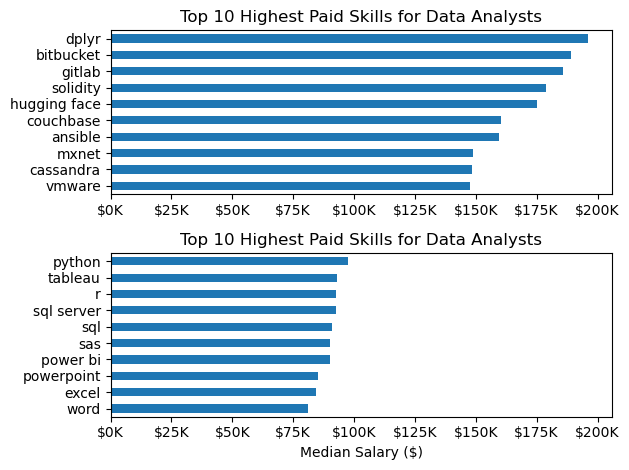

In [ ]:
fig, ax = plt.subplots(2, 1)

df_top_pay[::-1].plot(
    kind='barh', 
    y='median_salary', 
    ax=ax[0], 
    legend=False
)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(
    lambda  x, pos: f'${int(x/1000)}K'
))

df_top_skills_count[::-1].plot(
    kind='barh', 
    y='median_salary', 
    ax=ax[1], 
    legend=False
)
ax[1].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[1].set_xlabel('Median Salary ($)')
ax[1].set_ylabel('')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(
    lambda  x, pos: f'${int(x/1000)}K'
))

fig.tight_layout()
plt.show()